This notebook is a localization problem. Where I simulate the performance of a single contrast localizer of different thresholds compared to  multitask localizers

In [16]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import construct as ct
import itertools
import OptimalBattery.estimate as et
import matplotlib.cm as cm



In [17]:
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
base_dir = 'Y:/data'

# start with some U_true, in this simulation its 5 parcels

In [18]:
height = 30
width = 30
K_main = 5
K_subparcels = 1
K_total = 5

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=5, P=grid.P)
# define centroids more systematically
center_1 = (0, 0)
center_5 = (int((height-1)/2), int((width-1)/2))
center_2 = (width-1,0 )
center_4 = (height-1, width-1)
center_3 = (0, height-1)
centroids = [center_1, center_2, center_3, center_4, center_5]
print(centroids)


[(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [19]:
custom_cmap = plot.create_custom_colormap(['red', 'blue', 'green', 'yellow', 'purple'],K_subparcels=5)

In [20]:
def plot_Us(U,title = None):
    if type(U) == np.ndarray:
        U = pt.tensor(U)
    parcel_labels_plot = U.argmax(dim=0).numpy()
    parcel_labels_plot = parcel_labels_plot.reshape((height, width))
    plt.imshow(parcel_labels_plot, cmap=custom_cmap)
    if title is not None:
        plt.title(title)
    else:
        plt.title('figure')
    return
    

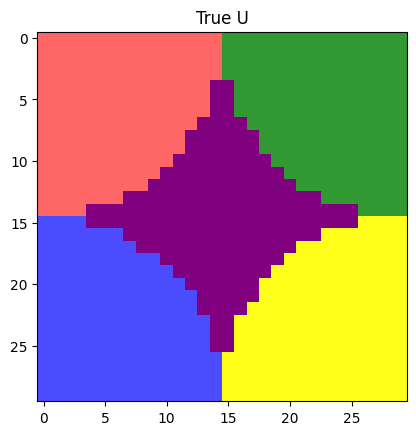

In [21]:
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_5 = pt.from_numpy(U_true_5).to(device=device, dtype=pt.float64)
arrangeT.logpi = pt.log(U_true_5)

plot_Us(U_true_5.cpu().numpy(), title = 'True U')

for the evaluations we will need to compare resulting Uhats to a Utrue and the U true needs to be collapsed into only the parcel of interest (parcel 5 and everything else)

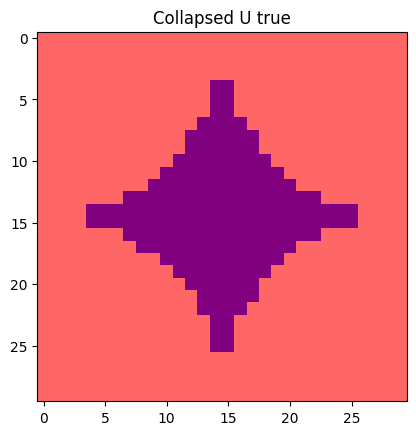

In [22]:
collapsed_U_true = sim.collapse_U(U_true_5, target_parcel_idx=4)
plot_Us(collapsed_U_true.cpu().numpy(), title='Collapsed U true')

# Run the analysis 

In [ ]:
battery_sizes = [3,4,5,6,7,8,12,16,20,24,28]
metrics = ['random','variance','variance_mc','log_det_mc','inverse_trace_mc']
num_task_lib = 100
n_parcels = 5
base_noise = 2 # the base noise affects which method (multi vs single) is better, with larger noise, single is better

n_sim = 50
n_batteries = 1000

In [24]:
D_multi = sim.sim_parcellation(num_task_lib = num_task_lib,
                    n_parcels = n_parcels,
                    U_true = U_true_5,
                    battery_sizes = battery_sizes,
                    n_batteries = n_batteries,
                    base_noise = base_noise,
                    n_sim = n_sim,
                    collapsed_U_true=collapsed_U_true)
D_multi.to_csv('localization_multi_sim.tsv',index=False,sep='\t')

Processing battery size: 3
Processing battery size: 4
Processing battery size: 5
Processing battery size: 6
Processing battery size: 7
Processing battery size: 8
Processing battery size: 12
Processing battery size: 16
Processing battery size: 20
Processing battery size: 24
Processing battery size: 28


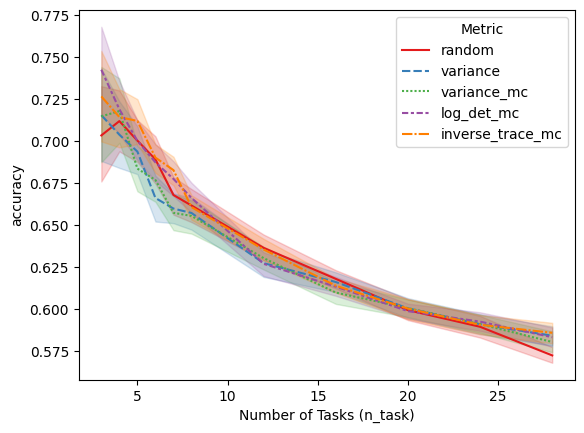

In [25]:
sns.lineplot(data=D_multi,x="n_task", y="accuracy", hue="metric", style='metric',palette="Set1")
plt.xlabel("Number of Tasks (n_task)")
plt.ylabel("accuracy")
plt.legend(title="Metric")
plt.show()

# single dimensional localizer

In [26]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,0.95,0.99]

In [27]:
D_single = sim.sim_single_contrast(num_task_lib = num_task_lib,
                            n_parcels = n_parcels,
                            U_true = U_true_5,
                            base_noise = base_noise,
                            max_battery_size = max(battery_sizes),
                            thresholds = thresholds,
                            U_true_collapsed = collapsed_U_true,
                            n_sim = 100)
D_single.to_csv('localization_single_sim.tsv',index=False,sep='\t')

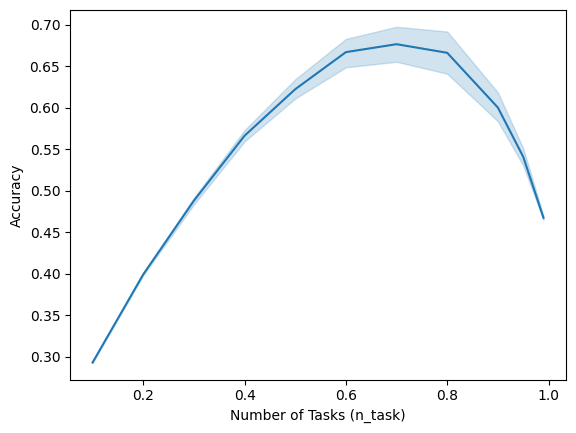

In [28]:
sns.lineplot(data=D_single,x="threshold", y="accuracy")
plt.xlabel("Number of Tasks (n_task)")
plt.ylabel("Accuracy")
plt.show()

# compare

In [29]:
metric_of_interest = 'log_det_mc'
D_multi_filtered = D_multi[D_multi['metric'] == metric_of_interest]
summary_multi = D_multi_filtered.groupby('n_task')['accuracy'].agg(['mean', 'sem']).reset_index()
summary_multi.columns = ['n_task', 'mean_accuracy', 'sem_accuracy']

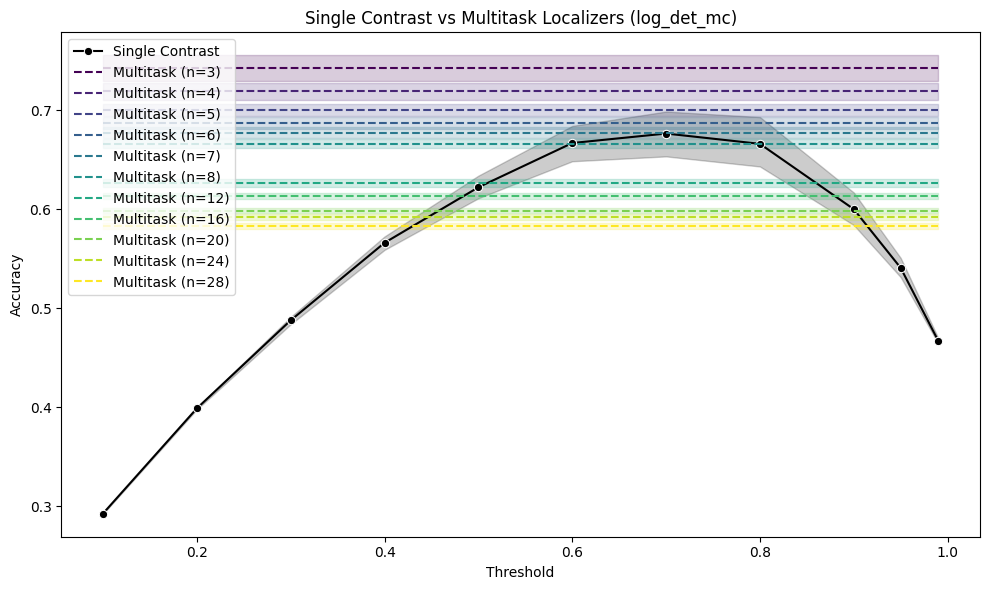

In [30]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=D_single,x="threshold", y="accuracy",label='Single Contrast',color='black',marker='o')


# add the multitask lines
colors = cm.viridis(np.linspace(0, 1, len(summary_multi)))
xmin = min(D_single['threshold'])
xmax = max(D_single['threshold'])

for i, row in summary_multi.iterrows():
    mean = row['mean_accuracy']
    sem = row['sem_accuracy']
    n_task = row['n_task']

    plt.hlines(
        y=mean,
        xmin=xmin,
        xmax=xmax,
        colors=[colors[i]],
        linestyles='dashed',
        label=f'Multitask (n={int(n_task)})'
    )

    plt.fill_between(
        [xmin, xmax],
        [mean - sem],
        [mean + sem],
        color=colors[i],
        alpha=0.2
    )

plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.title(f'Single Contrast vs Multitask Localizers ({metric_of_interest})')
plt.legend(loc='best')
plt.tight_layout()
plt.show()
